In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./licenciamento.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222625 entries, 0 to 222624
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            222625 non-null  object 
 1   modo                            222625 non-null  object 
 2   id_veiculo                      222625 non-null  object 
 3   ano_fabricacao                  222625 non-null  int64  
 4   carroceria                      222625 non-null  object 
 5   data_ultima_vistoria            200112 non-null  object 
 6   id_carroceria                   222625 non-null  int64  
 7   id_chassi                       222625 non-null  int64  
 8   id_fabricante_chassi            222625 non-null  int64  
 9   id_interno_carroceria           222625 non-null  int64  
 10  id_planta                       222625 non-null  int64  
 11  indicador_ar_condicionado       222625 non-null  bool   
 12  indicador_elevad

In [42]:
k = df.isna().sum() / len(df)
k = k[k>0]
print(k)

data_ultima_vistoria              0.101125
tecnologia                        0.280818
status                            0.139818
data_inicio_vinculo               0.396712
ano_ultima_vistoria_atualizado    0.250659
dtype: float64


<Axes: xlabel='tecnologia'>

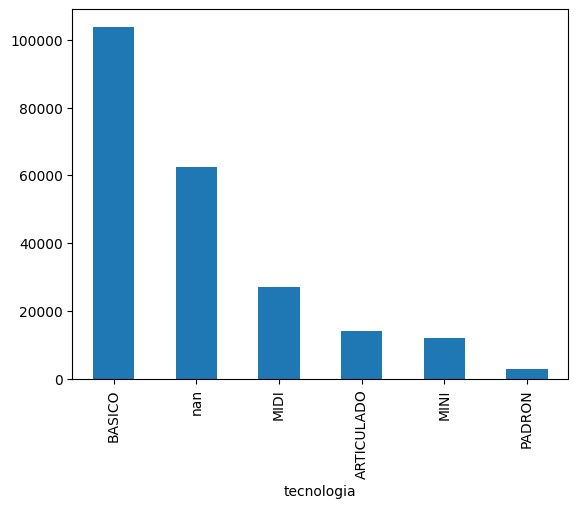

In [28]:
df["tecnologia"].value_counts(dropna=False).plot(kind="bar")

Estranho ter valores nulos nessa coluna, pois é uma caracterização bem fácil de fzr. De qqr qualquer forma, a princípio essa informação de tipo de onibus usado não é tao importante, ent possivelmente podemos descartar a coluna

In [ ]:
df['data_ultima_vistoria'] = pd.to_datetime(df['data_ultima_vistoria'])
print(df['data_ultima_vistoria'].head())


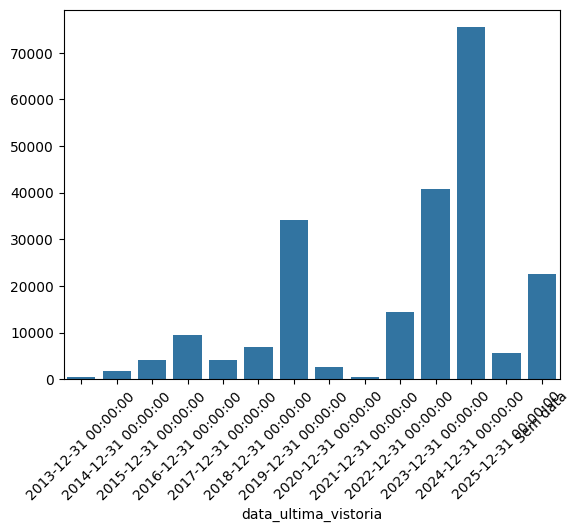

In [59]:
serie = df.groupby(pd.Grouper(key='data_ultima_vistoria', freq='YE')).size()
null_count = df['data_ultima_vistoria'].isna().sum()
serie.loc['Sem data'] = null_count
sns.barplot(serie)
plt.xticks(rotation=45)
plt.show()


É possivel que onde a data da ultima vistoria é nulo, se trate de onibus novos que ainda não tiveram tempo suficiente de frota

In [40]:
df_sem_vistoria = df[ df["data_ultima_vistoria"].isna()]
print(len(df_sem_vistoria))
print(df_sem_vistoria["ano_fabricacao"].value_counts())

#nao é issom tem veiculos velhos aqui

22513
ano_fabricacao
2023    14598
2024     1477
2013     1142
2019     1069
2015      873
2014      851
2016      837
2022      753
2017      412
2011      186
2012      150
2018       62
2025       58
2010       25
2009       17
2020        3
Name: count, dtype: int64


<Axes: xlabel='ano_ultima_vistoria_atualizado'>

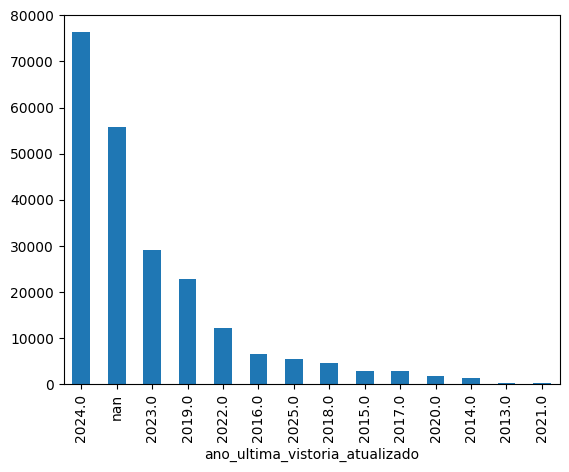

In [27]:
df["ano_ultima_vistoria_atualizado"].value_counts(dropna=False).plot(kind="bar")

Essa coluna é bizarra. Ela tem mais nulos que a coluna de data inteira da ultima vistoria! talvez seja possivel descartala e extrair o ano da outra coluna.

<Axes: xlabel='status'>

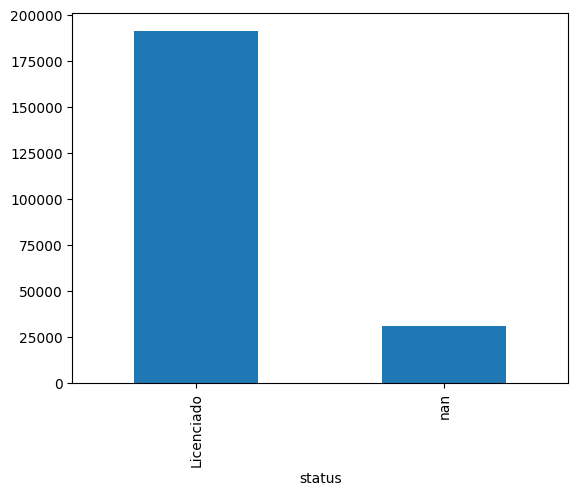

In [43]:
df["status"].value_counts(dropna=False).plot(kind="bar")

Aqui acredito que os NaN sejam os veículos não licenciados, pois caso contrario seria uma coluna com um unica valor, nao faz sentido. Mas oq é um 

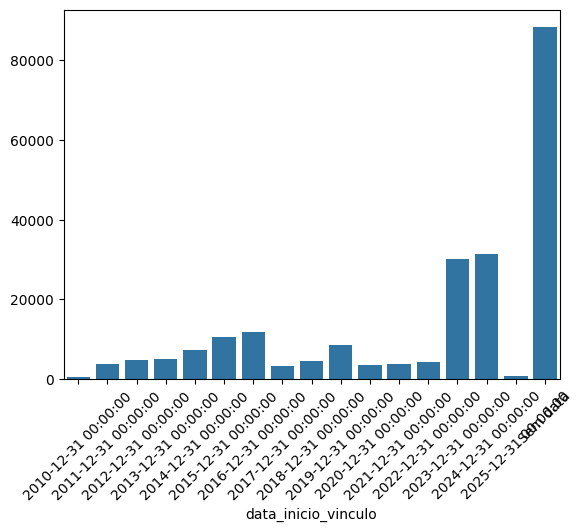

In [60]:
df['data_inicio_vinculo'] = pd.to_datetime(df['data_inicio_vinculo'])
serie = df.groupby(pd.Grouper(key='data_inicio_vinculo', freq='YE')).size()
null_count = df['data_inicio_vinculo'].isna().sum()
serie.loc['Sem data'] = null_count
sns.barplot(serie)
plt.xticks(rotation=45)
plt.show()

In [63]:
print(df['tipo_veiculo'].value_counts())

tipo_veiculo
51 ONIBUS BS URB C/AR C/E 2CAT    106223
45 BRT ARTICULADO                  17717
27 MINIONBUS URBAN C/AR C/ELEV     15466
31 ONBUS BASIC URB C/AR C/ELEV     13179
29 MIDIONBUS URBAN C/AR C/ELEV     10406
50 ONIBUS BS URB S/AR C/E 2CAT      9189
5 ONIBUS ROD. C/ AR                 8999
49 MIDI URB C/AR C/ELEV S/COBR      8945
48 MIDI URB S/AR C/ELEV S/COBR      8154
30 ONBUS BASIC URB S/AR C/ELEV      8091
28 MIDIONBUS URBAN S/AR C/ELEV      6571
61 RODOV. C/AR E ELEV               2997
44 BRT PADRON                       2559
53 MIDI URB C/AR C/ELEV 2 CATR      2327
42 ONIB PDRON URB P BAIXO C/AR      1166
26 MINIONBUS URBAN S/AR C/ELEV       570
52 MIDI URB S/AR C/ELEV 2 CATR        47
46 BRT BIARTICULADO                   17
43 ONIB PDRON URB P BAIXO S/AR         2
Name: count, dtype: int64


In [66]:
print(df['carroceria'].value_counts())

carroceria
INDUSCAR - CAIO        79945
NEOBUS - SAN MARINO    51742
MARCOPOLO              38149
MARCOLOPO S/A.         12305
INDUSCAR CAIO          11520
CAIO                    8391
SAN MARINO - NEOBUS     5298
MASCARELLO              4917
MARCOPOLO S/A.          2503
MARCOPLO                2113
COMIL                   1397
BUSSCAR                  998
INDUSCAR                 965
MARCOPOLO S.A.           947
MARCOPOLO S.A            573
MARCOPOLO VIALE          516
MARCOPLO S.A.            320
NEOBUS                    26
Name: count, dtype: int64


# Empresas

O dataset atualmente nao contém dados sobre empresas, porém os ids dos carros tem prefixos onde os tres primeiros digique indicam a empresa. Buscando o prefixo correspondente a cada empresa, criar nova coluna contendo o nome da empresa a qual cada veiculo pertence.

In [68]:
df_test = df[["data_inicio_vinculo", "ano_fabricacao"]]
df_test.corr()

,data_inicio_vinculo,ano_fabricacao
data_inicio_vinculo,1.000000,0.263527
ano_fabricacao,0.263527,1.000000
